# Clinico-Transcriptomic Discovery of Prognostic Biomarkers and Functional Hallmarks in TCGA Breast Cancer Using Python
---
   ## Notebook 4: Functional Enrichment Analysis

### 1. Biological Motivation

Notebook 3 identified a set of genes whose expression differed significantly between patients who survived and those who died. While individual genes provide valuable biomarkers, genes rarely function in isolation. Instead, they operate as components of larger biological pathways that regulate proliferation, metabolism, immune surveillance, differentiation, and tissue organization.

The objective of this notebook is to move beyond individual genes and determine whether the observed transcriptional changes converge on coordinated biological processes associated with poor clinical outcome.

To achieve this, two complementary enrichment strategies are employed:

- Over-Representation Analysis (ORA) using Enrichr to determine whether the significantly downregulated genes are enriched within known biological pathways.
- Gene Set Enrichment Analysis (GSEA) using a genome-wide ranked gene list to identify coordinated activation or suppression of hallmark biological programs without imposing arbitrary significance thresholds.

This notebook addresses the following biological questions:

> Which biological pathways are preferentially lost in patients with poor survival?

> Which cellular programs become activated during aggressive disease progression?

> Which biological systems are consistently suppressed?

> How do these pathway-level findings explain the individual genes identified in Notebook 3?

### 2. Import Required Libraries

In [1]:
import os
import gseapy as gp

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid")

### 3. Load Differential Expression Results

The master differential expression table generated in Notebook 3 serves as the starting point for pathway analysis.

In [2]:
dgea_results = pd.read_csv("../results/tables/brca_dgea_master_results.csv")

### 4. Over-Representation Analysis (ORA)

#### 4.1 Why ORA?

Differential expression identifies genes individually.

ORA instead asks:

> *Are these significant genes concentrated within particular biological pathways more often than expected by chance?*

Because Notebook 3 showed that poor-survival tumors were overwhelmingly characterized by **gene suppression**, we focus specifically on the downregulated genes.



#### 4.2 Extract Downregulated Genes

In [3]:
downregulated_genes = dgea_results[dgea_results["Significance"] == "Downregulated (Dead)"]["gene_name"].dropna().tolist()

print(f"Extracted {len(downregulated_genes)} downregulated genes for pathway mapping.")

Extracted 168 downregulated genes for pathway mapping.


####  4.3 Enrichment Against KEGG and Gene Ontology

In [4]:
print("Running Enrichment Analysis against KEGG and Gene Ontology...")

libraries = ["KEGG_2021_Human", "GO_Biological_Process_2021"]

enr = gp.enrichr(
    gene_list=downregulated_genes,      # Our target gene pool
    gene_sets=libraries,                 # The databases we want to scan
    organism="human",                    # Organism must match
    outdir=None,                         # Keep results in memory first
)

enrich_results = enr.results


Running Enrichment Analysis against KEGG and Gene Ontology...


Only pathways with an adjusted p-value below 0.05 were retained.


In [5]:
significant_pathways = enrich_results[enrich_results["Adjusted P-value"] < 0.05]
print(f"Number of highly significant biological pathways found: {significant_pathways.shape[0]}")


significant_pathways.head()

Number of highly significant biological pathways found: 3


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Neuroactive ligand-receptor interaction,16/341,3.174913e-08,0.000004,0,0,6.318057,109.083780,GRIA1;GABBR2;CHRNA4;GCGR;NPY2R;CHRNA9;ADRB1;TR...
1,KEGG_2021_Human,Tyrosine metabolism,4/36,2.294129e-04,0.015485,0,0,15.091463,126.466272,PNMT;ALDH3A1;TAT;TYRP1
135,GO_Biological_Process_2021,epithelial structure maintenance (GO:0010669),4/18,1.340785e-05,0.014507,0,0,34.526132,387.371809,MUC2;TFF2;TFF1;LACRT


#### Interpretation of ORA Results:
    
Rather than revealing dozens of unrelated biological processes, the downregulated genes converged upon three tightly connected systems that collectively describe the collapse of normal breast epithelial biology.

**1. Neuroactive Ligand–Receptor Interaction**: This was the strongest enriched pathway identified, with an adjusted p-value ≈ 4 × 10⁻⁶. Sixteen pathway genes were represented.

This pathway contains receptors and signaling molecules responsible for intercellular communication, including neurotransmitter receptors, hormone receptors, and neuropeptide signaling proteins.

Examples include:

* GABBR2
* CHRNA4
* NPY2R
* ADRB1

In healthy breast tissue, these signaling networks help maintain normal tissue homeostasis by allowing cells to respond appropriately to systemic physiological cues.

Their coordinated suppression suggests that aggressive tumors progressively lose sensitivity to external regulatory signals.

Rather than remaining integrated within normal tissue physiology, cancer cells become increasingly autonomous, allowing uncontrolled growth despite inhibitory environmental signals.


**2. Epithelial Structure Maintenance**: 

Genes within this pathway maintain epithelial organization through:

* barrier formation
* cell adhesion
* extracellular integrity
* tissue architecture

Representative genes include:

* MUC2
* TFF1
* TFF2
* LACRT

The loss of this pathway represents a hallmark of epithelial-to-mesenchymal transition (EMT), during which epithelial cells lose polarity and adhesion, acquire migratory properties, and gain invasive potential.

Consequently, suppression of epithelial maintenance provides a mechanistic explanation for the increased metastatic capacity associated with poor survival.


**3. Tyrosine Metabolism**

Tyrosine serves as a precursor for numerous signaling molecules and metabolic intermediates required for normal cellular function.

Its suppression suggests that aggressive tumors undergo profound metabolic rewiring, abandoning normal biosynthetic pathways in favor of alternative metabolic programs optimized for rapid proliferation and survival under stressful conditions.


 > **Summary of ORA Findings**

Collectively, these three pathways define the core biological architecture lost during aggressive breast cancer progression:

* disruption of cellular communication
* collapse of epithelial integrity
* metabolic reprogramming

These findings suggest that poor survival is driven not simply by activation of oncogenic pathways, but by widespread loss of normal tissue identity.



In [6]:
significant_pathways.to_csv("../results/tables/brca_pathways_output.csv", index=False)
print("Pathway enrichment spreadsheet saved to results directory successfully!")

Pathway enrichment spreadsheet saved to results directory successfully!


### 5. Gene Set Enrichment Analysis (GSEA)

#### 5.1. Why Perform GSEA?

ORA analyzes only statistically significant genes.

However, many biologically meaningful pathways involve modest but coordinated expression changes across hundreds of genes.

GSEA addresses this limitation by evaluating the entire transcriptome simultaneously, allowing subtle but coordinated biological programs to be detected.



#### 5.2. Ranking the Entire Transcriptome

Genes were ranked according to both the direction and strength of differential expression.

This ranking prioritizes genes that exhibit both strong statistical evidence and consistent direction of change.

In [7]:
dgea_results["ranking_metric"] = np.sign(dgea_results["log2FoldChange"]) * (-np.log10(dgea_results["pvalue"]))

rnk_df = dgea_results[["gene_name", "ranking_metric"]].dropna().sort_values(by="ranking_metric", ascending=False)

print(f"Total genes successfully ranked for Hallmark GSEA: {rnk_df.shape[0]}")

Total genes successfully ranked for Hallmark GSEA: 16790


#### 5.3. Hallmark Gene Set Enrichment

In [8]:
print("\n--- Running gseapy.prerank against MSigDB_Hallmark_2020 ---")
pre_res = gp.prerank(
    rnk=rnk_df,
    gene_sets="MSigDB_Hallmark_2020",
    organism="human",
    outdir=None,              
    permutation_num=1000,     
    min_size=15,              
    max_size=500,             
    seed=42                   
)

hallmark_results = pre_res.res2d.copy()

significant_hallmarks = hallmark_results[hallmark_results["NOM p-val"] < 0.05].copy()
significant_hallmarks = significant_hallmarks.sort_values(by="NES", ascending=False)

print(f"Number of significant Hallmark pathways discovered: {significant_hallmarks.shape[0]}")


--- Running gseapy.prerank against MSigDB_Hallmark_2020 ---
Number of significant Hallmark pathways discovered: 22


In [9]:
significant_hallmarks.head(10)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,E2F Targets,0.574993,2.504823,0.001000,0.001000,0.001,101/200,25.11%,GINS4;MRE11;MTHFD2;PAICS;RFC3;CDC25B;RAD21;BRM...
1,prerank,Myc Targets V1,0.540045,2.336364,0.001000,0.001000,0.001,70/200,14.66%,PGK1;PTGES3;VDAC3;VDAC1;NCBP1;TCP1;RAD23B;EIF1...
2,prerank,G2-M Checkpoint,0.513697,2.208386,0.001000,0.001000,0.001,103/199,25.11%,KIF5B;RAD23B;CDC25B;RAD21;EFNA5;MAD2L1;UCK2;CD...
4,prerank,mTORC1 Signaling,0.427305,1.838582,0.001000,0.001114,0.001,61/200,16.01%,PGK1;MTHFD2;PSMD12;PNO1;PSMD14;HSPA9;STIP1;RAB...
5,prerank,Unfolded Protein Response,0.457454,1.837114,0.001000,0.001000,0.001,26/113,10.97%,KIF5B;MTHFD2;CNOT6;GOSR2;HSPA9;YWHAZ;SDAD1;ALD...
8,prerank,Protein Secretion,0.435506,1.720274,0.001000,0.005941,0.008,45/96,20.58%,OCRL;GOSR2;RAB5A;STAM;ZW10;RAB2A;ARCN1;LAMP2;Y...
9,prerank,Oxidative Phosphorylation,0.395234,1.677928,0.001000,0.010821,0.017,53/200,16.74%,VDAC3;VDAC2;OPA1;VDAC1;CS;PDP1;ETFA;DLAT;HADHA...
10,prerank,Myc Targets V2,0.464852,1.67777,0.012579,0.009469,0.017,24/58,24.31%,MPHOSPH10;HSPD1;MCM4;SLC19A1;AIMP2;PLK1;MYC;DC...
17,prerank,Glycolysis,0.347597,1.483248,0.001000,0.033172,0.066,81/194,25.70%,PGK1;PDK3;AGL;MXI1;B3GNT3;P4HA1;PRPS1;LCT;SDC1...
22,prerank,Mitotic Spindle,0.293423,1.273736,0.001000,0.135014,0.261,42/198,15.05%,RABGAP1;FSCN1;KIF5B;NET1;CDC27;LRPPRC;ABI1;RAS...


#### Interpretation of Hallmark Pathways

The enriched Hallmark pathways naturally separated into two opposing biological themes.

**1. Activated Programs in Poor-Survival Tumors**

Several pathways showed strong positive normalized enrichment scores (NES), indicating increased activity in patients who died.

> **E2F Targets:** The strongest activated pathway. E2F transcription factors regulate DNA synthesis and entry into the cell cycle. Their activation indicates uncontrolled cellular proliferation.

> **MYC Targets:** Both MYC Hallmark collections were significantly enriched. MYC is a master regulator of, ribosome biogenesis, nucleotide synthesis, protein production and cellular growth. Its activation indicates that tumor biosynthetic machinery has been extensively rewired to support rapid proliferation.

> **G2/M Checkpoint:** Activation of this pathway reflects increased mitotic activity and accelerated cell division. Together with E2F and MYC activation, it defines a highly proliferative tumor phenotype.

> **mTORC1 Signaling:** mTORC1 regulates nutrient sensing, protein synthesis, and cell growth. Its activation demonstrates that aggressive tumors maintain sustained anabolic signaling despite environmental stress.

> **Glycolysis and Oxidative Phosphorylation:** Interestingly, both major energy-producing pathways were enriched. Rather than relying exclusively on aerobic glycolysis, poor-survival tumors appear metabolically flexible, simultaneously increasing glycolytic and mitochondrial energy production to satisfy exceptionally high energetic demands.

> **Unfolded Protein Response:** Rapid proliferation produces substantial protein-folding stress. Activation of the unfolded protein response enables cancer cells to tolerate this burden, preventing apoptosis despite increased biosynthetic activity.


**2. Suppressed Programs in Poor-Survival Tumors**

Several hallmark pathways displayed negative enrichment scores, indicating coordinated suppression.

> **Estrogen Response:** Both early and late estrogen response pathways were significantly suppressed. This observation is clinically important. Breast tumors retaining estrogen responsiveness generally have more favorable prognoses and remain susceptible to endocrine therapy. Loss of estrogen signaling therefore suggests progression toward a more aggressive, dedifferentiated phenotype.

> **Interferon Alpha and Gamma Responses:** These pathways represent central components of anti-tumor immune surveillance. Their suppression indicates that aggressive tumors actively evade immune detection by disabling interferon-mediated signaling.

> **Allograft Rejection:** Although originally defined within transplant biology, this hallmark reflects cytotoxic T-cell activation and immune-mediated tissue destruction. Its suppression further supports the emergence of an immunologically "cold" tumor microenvironment.

> **Complement:** Reduced complement signaling suggests diminished innate immune activation, contributing further to immune escape.

**Integrating Notebook 3 with Systems Biology**

One of the central questions arising from Notebook 3 was whether the eight highly significant upregulated genes represented isolated findings or components of larger biological systems. The pathway analyses demonstrate that these genes are embedded within broader oncogenic programs.

- For example, **NOS1**, one of the strongest upregulated genes, is closely associated with the metabolic remodeling observed through activation of glycolysis and mTORC1 signaling. Increased nitric oxide signaling has been implicated in promoting metabolic adaptation under hypoxic conditions, enabling continued tumor growth despite environmental stress.

- Similarly, **TRIM67**, the most statistically significant upregulated gene, functions as an E3 ubiquitin ligase and is mechanistically linked to protein quality control. Its increased expression is consistent with activation of the unfolded protein response, a pathway that protects rapidly proliferating cells from proteotoxic stress.

- Other highly expressed genes, including **ALB**, **CEL**, and **CSN3**, reflect abnormal lineage-specific gene expression. Their appearance alongside suppression of estrogen signaling and epithelial maintenance suggests extensive loss of normal breast epithelial identity, consistent with dedifferentiation and increased tumor plasticity.

Taken together, the individual biomarkers identified in Notebook 3 emerge not as isolated molecular events, but as representative components of larger biological networks driving aggressive disease.


In [10]:
# Save this master GSEA table to your files
significant_hallmarks.to_csv("../results/tables/brca_preranked_gsea_results.csv", index=True)
print("Master pre-ranked GSEA results saved successfully!")

Master pre-ranked GSEA results saved successfully!


### 6. Visualization of Hallmark Enrichment

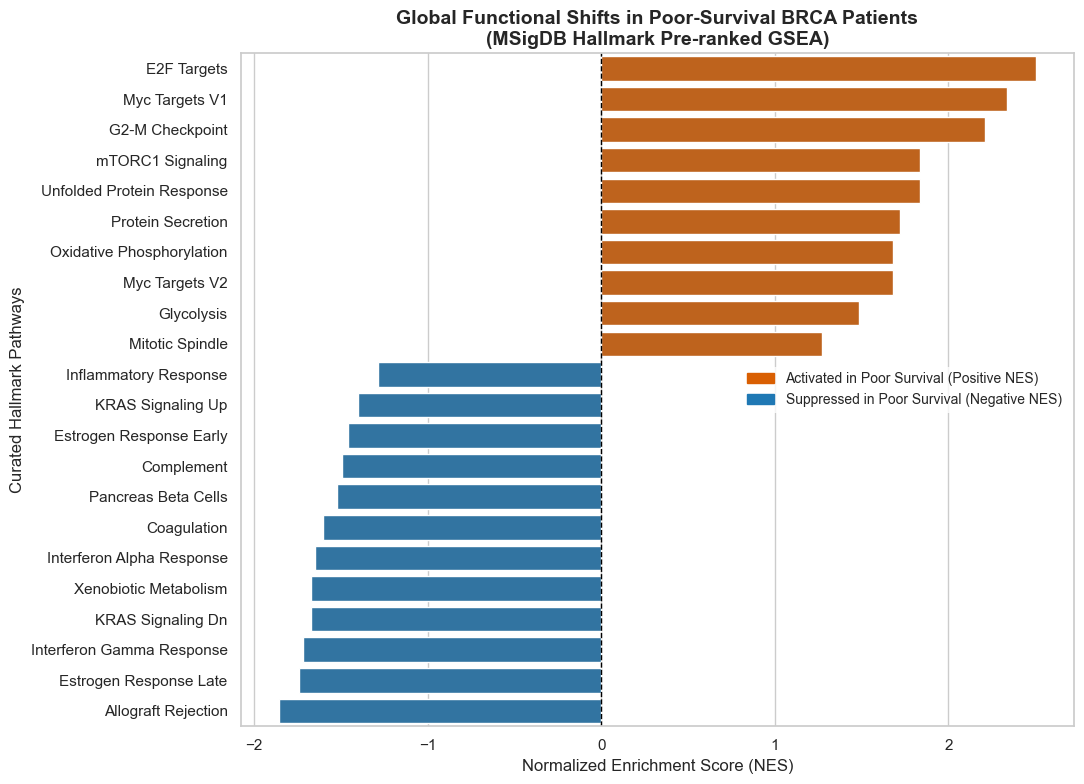

In [11]:
# Ensure your results are sorted by NES
plot_df = significant_hallmarks.sort_values(by="NES", ascending=False).copy()

# Clean up the Term names for readability
plot_df["Clean_Term"] = (plot_df["Term"].str.replace("HALLMARK_", "").str.replace("_", " "))

# Set up the plot style
plt.figure(figsize=(11, 8))  # Slightly wider to comfortably accommodate the legend

# Define explicit color hex codes
pos_color = "#d95f02"  # Custom warning orange/red
neg_color = "#1f78b4"  # Custom slate blue

# Create a color vector for the individual bars
colors = [pos_color if x > 0 else neg_color for x in plot_df["NES"]]

# Draw horizontal barplot
sns.barplot(
    x="NES",
    y="Clean_Term",
    data=plot_df,
    palette=colors,
    hue="Clean_Term",  # Avoids upcoming seaborn warnings
    legend=False,
)

# Add statistical markings: draw a vertical dashed line at zero
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)

# Create artificial "patches" (color swatches) for the legend
pos_patch = mpatches.Patch(color=pos_color, label="Activated in Poor Survival (Positive NES)")
neg_patch = mpatches.Patch(color=neg_color, label="Suppressed in Poor Survival (Negative NES)")

# Place the legend on the plot
plt.legend(
    handles=[pos_patch, neg_patch],
    loc="center right",
    fontsize=10,
    frameon=True,
    facecolor="white",
    edgecolor="none",
)


# Labels and Styling
plt.title("Global Functional Shifts in Poor-Survival BRCA Patients\n(MSigDB Hallmark Pre-ranked GSEA)", fontsize=14, fontweight="bold")
plt.xlabel("Normalized Enrichment Score (NES)", fontsize=12)
plt.ylabel("Curated Hallmark Pathways", fontsize=12)

# Adjust margins to fit long text safely
plt.tight_layout()
plt.savefig(f"../results/figures/gsea_enrichment_barplot.png", dpi=300, bbox_inches="tight",)
plt.show()

### Notebook summary

This systems-level analysis reveals that poor-survival breast tumors are characterized by two simultaneous biological processes.

* First, tumors acquire highly active proliferative and metabolic programs driven by E2F, MYC, mTORC1 signaling, glycolysis, oxidative phosphorylation, and enhanced protein quality control.
* Second, they progressively lose normal epithelial identity through suppression of estrogen signaling, epithelial maintenance, immune surveillance, and intercellular communication.

Rather than representing isolated molecular abnormalities, these coordinated pathway alterations define a comprehensive transcriptional program underlying aggressive breast cancer progression.

By integrating differential expression analysis with pathway enrichment, this notebook transforms a list of statistically significant genes into a coherent biological model of disease progression.

The results suggest that poor clinical outcome arises through a combination of uncontrolled proliferation, metabolic adaptation, immune evasion, and progressive loss of epithelial differentiation.

These pathway-level insights provide the biological foundation for the predictive modeling developed in the next stage of the analysis pipeline.
